# 0. 環境構築

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import japanize_matplotlib
import seaborn as sns

%matplotlib inline

g++ not available, if using conda: `conda install gxx`


In [2]:
#-----------------------------------------------
#grapfvizの設定
#-----------------------------------------------

import os
import sys

# Graphvizの bin フォルダのパスを指定 (環境に合わせて変更してください)
graphviz_path = r"C:\Program Files\Graphviz\bin"

# PATHに一時的に追加
os.environ["PATH"] += os.pathsep + graphviz_path

# この後に graphviz や pydot を呼び出す
import graphviz

# 1. ベイズ回帰モデル

## 1-1. EDA

In [3]:
df = pd.read_csv(pm.get_data('test_scores.csv'), index_col=0)
df

,score,male,siblings,family_inv,non_english,prev_disab,age_test,non_severe_hl,mother_hs,early_ident,non_white
0,40,0,2.0,2.0,False,NaN,55,1.0,NaN,False,False
1,31,1,0.0,NaN,False,0.0,53,0.0,0.0,False,False
2,83,1,1.0,1.0,True,0.0,52,1.0,NaN,False,True
3,75,0,3.0,NaN,False,0.0,55,0.0,1.0,False,False
5,62,0,0.0,4.0,False,1.0,50,0.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...
220,68,0,2.0,2.0,False,0.0,53,0.0,1.0,True,False
221,104,1,2.0,0.0,False,0.0,52,1.0,1.0,False,False
222,71,1,1.0,NaN,False,0.0,57,1.0,NaN,False,True
223,118,0,2.0,0.0,False,0.0,57,1.0,NaN,True,False


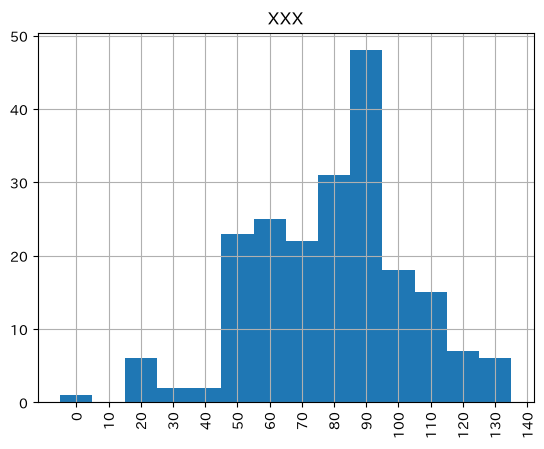

In [4]:
bins = np.arange(0, 150, 10)
fig, ax = plt.subplots()
df['score'].hist(bins=bins, align='left')
plt.setp(ax.get_xticklabels(), rotation=90)
plt.title('XXX')
plt.xticks(bins)
plt.show()

## 1-2. データ加工

In [5]:
#欠損値の削除
df1 = df.dropna().astype(float)

print(f'データ件数{len(df1)}\n')

データ件数101



In [6]:
y = df1.pop("score") #pandas.Dataframe.pop()はデータフレームから列を切り離す
X = df1.copy()

In [7]:
#データ X の各要素から、全体の平均値（X.mean()）を引いています
X -= X.mean()

#中心化したデータを、全体の標準偏差（X.std()）で割っています
X /= X.std()

display(X)

,male,siblings,family_inv,non_english,prev_disab,age_test,non_severe_hl,mother_hs,early_ident,non_white
7,-1.004938,1.078165,2.227502,2.480475,1.782293,-0.978004,1.179344,0.616250,-0.772789,1.132532
12,0.985234,-0.080289,-0.911722,-0.399157,-0.555520,-1.562492,1.179344,0.616250,1.281203,-0.874235
14,-1.004938,1.078165,-0.911722,-0.399157,-0.555520,1.359947,1.179344,0.616250,1.281203,1.132532
19,0.985234,-1.238742,1.181094,-0.399157,-0.555520,-0.978004,1.179344,0.616250,-0.772789,1.132532
21,0.985234,-0.080289,1.181094,-0.399157,1.782293,1.359947,-0.839533,-1.606652,1.281203,1.132532
...,...,...,...,...,...,...,...,...,...,...
212,-1.004938,-0.080289,0.134686,-0.399157,-0.555520,1.359947,-0.839533,-1.606652,-0.772789,1.132532
216,-1.004938,-0.080289,-0.911722,-0.399157,-0.555520,1.652191,1.179344,0.616250,-0.772789,-0.874235
218,0.985234,1.078165,0.134686,2.480475,-0.555520,-0.393517,1.179344,0.616250,-0.772789,1.132532
220,-1.004938,1.078165,1.181094,-0.399157,-0.555520,-0.101273,-0.839533,0.616250,1.281203,-0.874235


In [8]:
#データ件数と項目数の設定
N, D = X.shape

#項目名一覧を columnsに設定
columns = X.columns.values

## 1-3. モデル定義

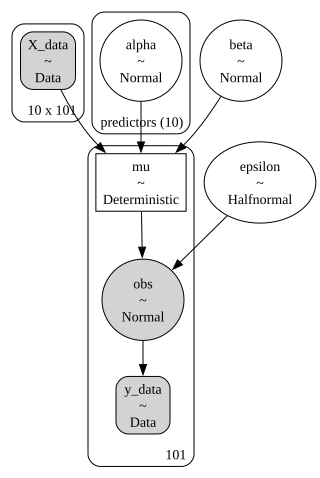

In [9]:
model1 = pm.Model(coords={'predictors':columns})

with model1:
    X_data = pm.Data('X_data', X.T)
    y_data = pm.Data('y_data', y)
    
    alpha= pm.Normal('alpha', mu=0, sigma=10, dims='predictors')
    
    beta = pm.Normal('beta', mu=100, sigma=25)
    epsilon = pm.HalfNormal('epsilon', sigma=25)
    
    mu = pm.Deterministic('mu', alpha @ X_data + beta)
    obs = pm.Normal('obs', mu=mu, sigma=epsilon, observed=y_data)
    
g = pm.model_to_graphviz(model1)
display(g)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, epsilon]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[male],1.04,1.78,-1.7,3.9,4693,3113,1.00,0.026,0.029
alpha[siblings],-1.97,1.84,-4.9,0.92,3763,2983,1.00,0.03,0.026
alpha[family_inv],-9.24,2.14,-13,-5.9,3349,3069,1.00,0.037,0.033
alpha[non_english],-3.75,1.87,-6.7,-0.72,4248,3140,1.00,0.029,0.029
alpha[prev_disab],-5.12,1.87,-8,-2.1,3971,3103,1.00,0.03,0.03
alpha[age_test],1.63,1.87,-1.4,4.6,3935,3052,1.00,0.03,0.028
alpha[non_severe_hl],2.83,1.8,-0.14,5.7,3901,2850,1.00,0.029,0.029
alpha[mother_hs],0.26,1.98,-2.9,3.4,3579,3188,1.00,0.033,0.029
alpha[early_ident],4.25,1.77,1.5,7.1,4484,3135,1.00,0.026,0.031
alpha[non_white],-2.85,1.97,-6,0.32,4253,3136,1.00,0.03,0.029


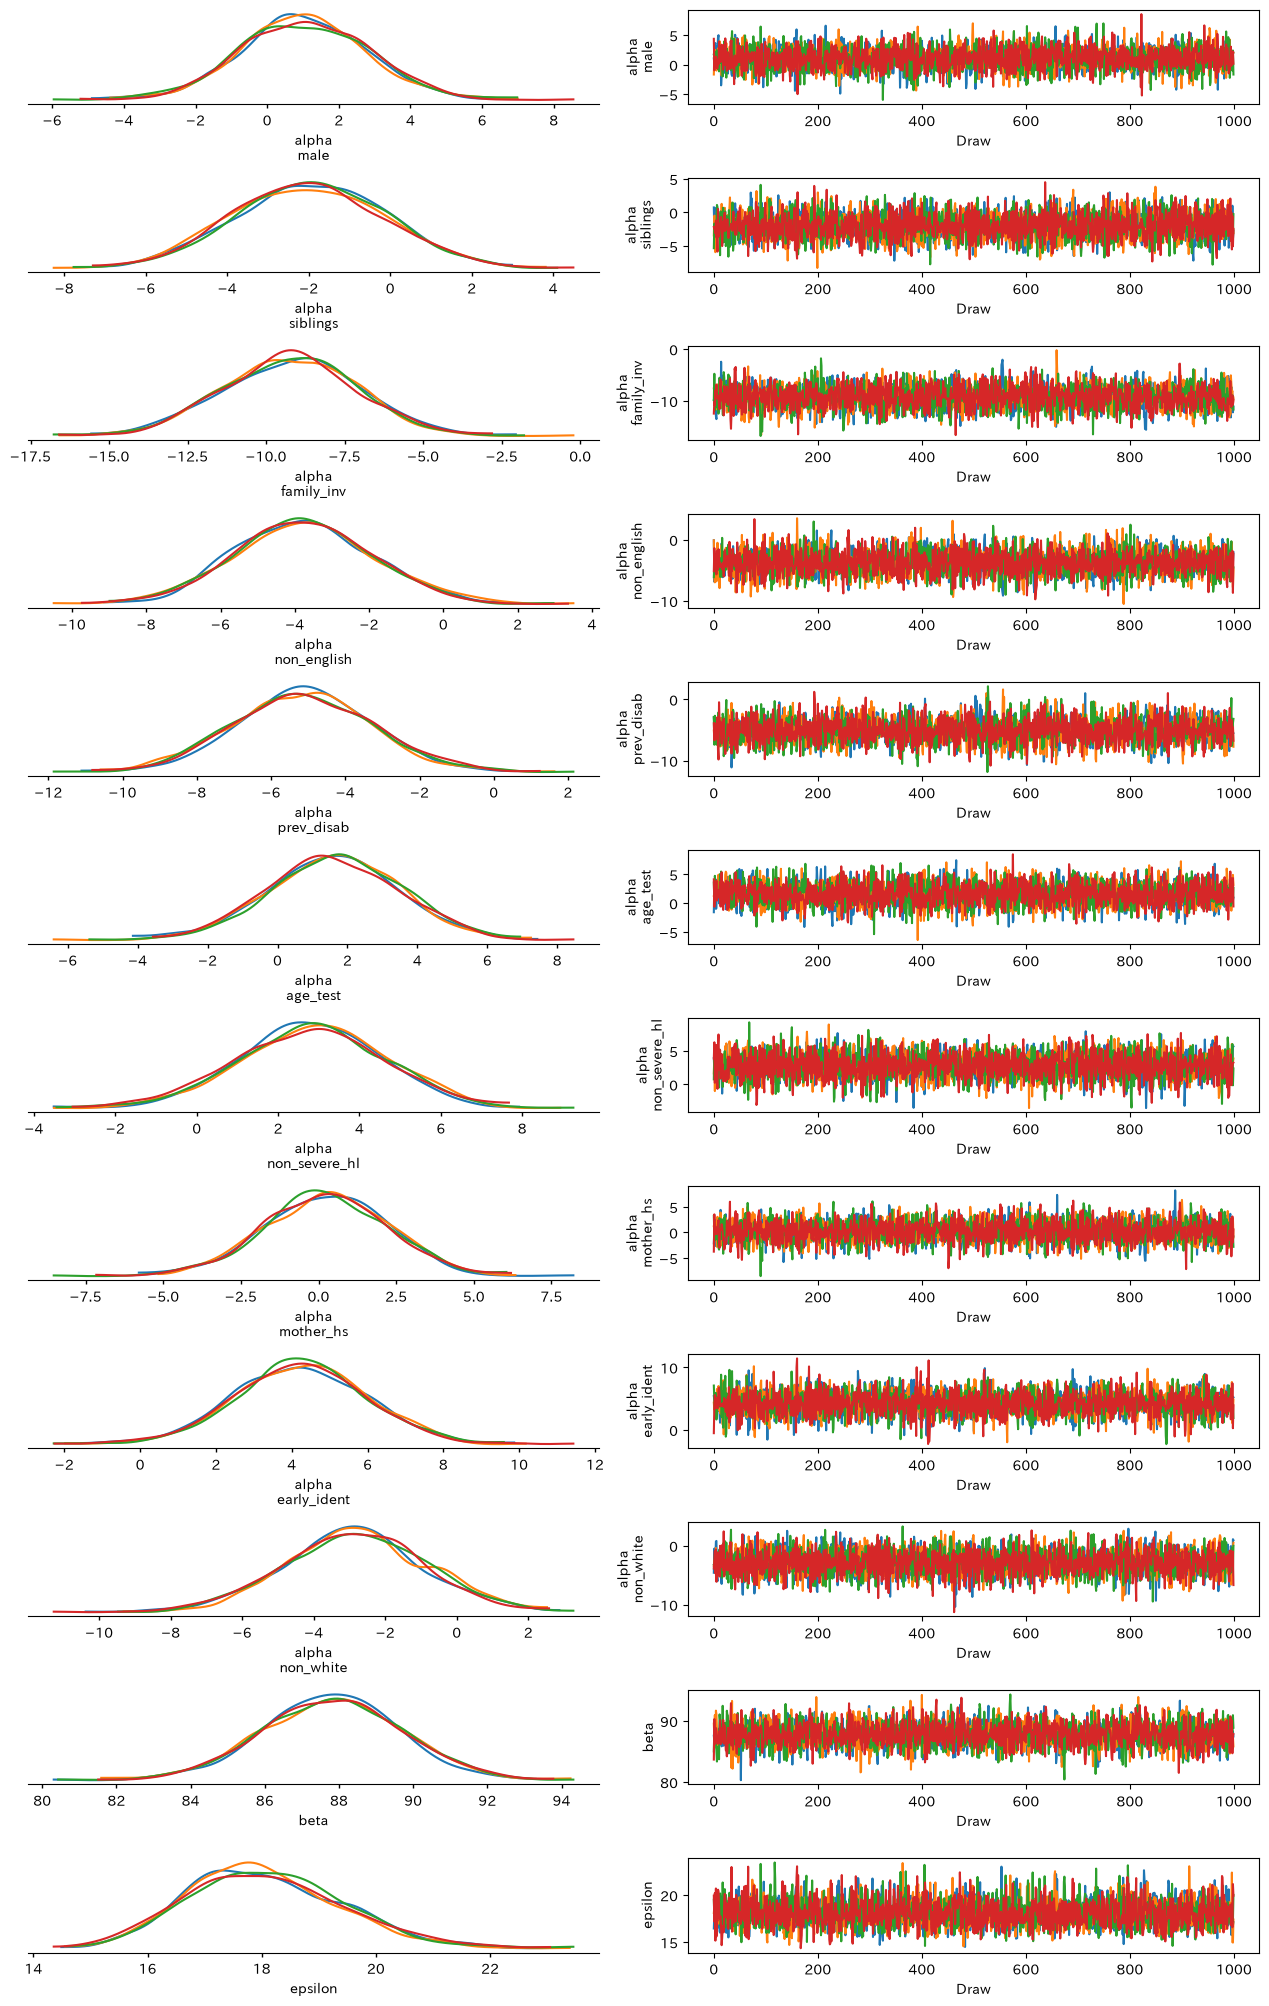

In [10]:
with model1:
    idata1 = pm.sample(random_seed=42, target_accept=0.95)

display(azs.summary(idata1, var_names=['alpha', 'beta', 'epsilon']))
azp.plot_trace_dist(idata1, var_names=['alpha', 'beta', 'epsilon'], compact=False)
plt.tight_layout()

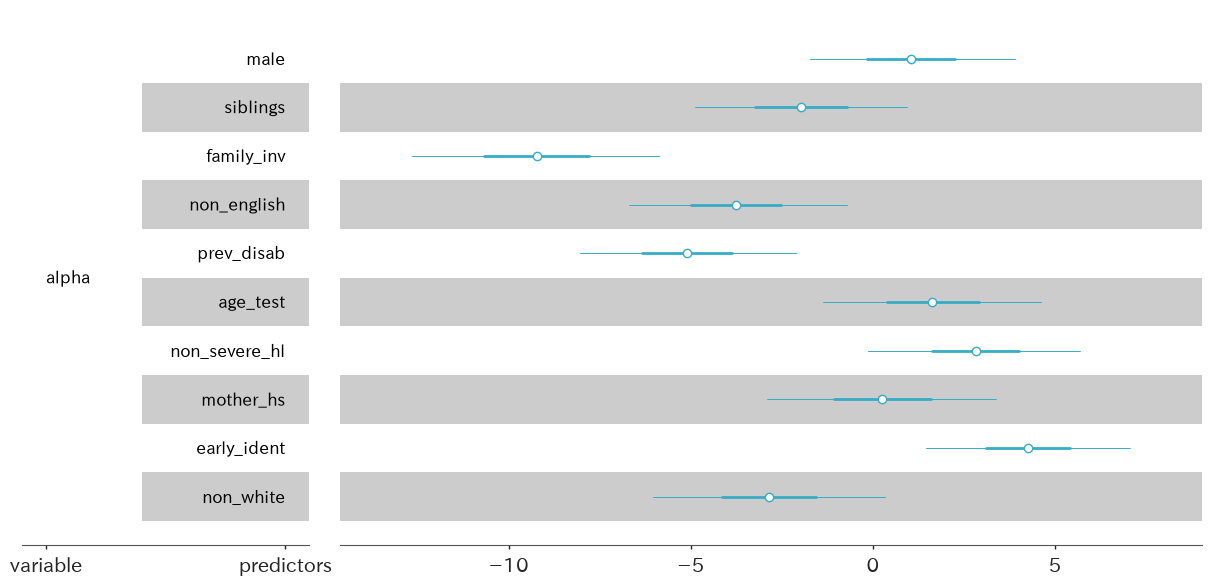

In [18]:
#azp.style.use("arviz-variat")
azp.plot_forest(idata1, var_names=['alpha'], combined=True, shade_label='predictors')  # change to preferred backend)

# 2. IRT（Item Response Theory）

## 2-1. データ作成

In [21]:
url = 'https://github.com/makaishi2/samples/raw/main/data/irt-sample.csv'
df = pd.read_csv(url, index_col=0)

df

,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,...,Q041,Q042,Q043,Q044,Q045,Q046,Q047,Q048,Q049,Q050
USER0001,0,1,1,1,0,1,1,0,0,0,...,0,0,1,1,0,1,0,1,1,1
USER0002,1,0,1,1,1,0,1,1,0,0,...,0,1,1,0,1,0,0,1,1,0
USER0003,1,0,1,1,1,1,1,1,0,0,...,1,1,1,1,1,1,1,1,1,1
USER0004,1,1,1,1,1,0,1,0,1,0,...,0,0,1,1,1,1,0,0,0,1
USER0005,0,1,0,1,0,0,1,0,1,1,...,1,1,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USER0996,1,1,0,1,1,1,1,0,0,1,...,0,1,1,1,0,0,1,0,0,1
USER0997,0,0,0,1,1,1,1,1,0,1,...,1,1,1,0,1,0,1,1,1,1
USER0998,1,1,0,1,1,1,1,1,1,0,...,1,1,1,1,1,0,0,1,1,1
USER0999,1,0,0,1,1,1,1,0,0,1,...,0,1,1,1,0,0,0,1,0,1


In [ ]:
#----------------------------------------------------------------------
#縦持ち変換
#----------------------------------------------------------------------

response_df = pd.melt(
    df.reset_index(), id_vars='index',
    var_name='question', value_name='response'
)

response_df = response_df.rename({'index':'user'}, axis=1)


#----------------------------------------------------------------------
#カテゴリデータの数値化
#----------------------------------------------------------------------

#user_idをindex化 usersにはindexと対応するuser_idが格納されている
user_idx, users = pd.factorize(response_df['user'])

question_idx, questions = pd.factorize(response_df['question'])

response = response_df['response'].values

print(user_idx, len(user_idx))
print(question_idx, len(question_idx))
print(response)

[  0   1   2 ... 997 998 999] 50000
[ 0  0  0 ... 49 49 49] 50000
[0 1 1 ... 1 1 1]


Index(['USER0001', 'USER0002', 'USER0003', 'USER0004', 'USER0005', 'USER0006',
       'USER0007', 'USER0008', 'USER0009', 'USER0010',
       ...
       'USER0991', 'USER0992', 'USER0993', 'USER0994', 'USER0995', 'USER0996',
       'USER0997', 'USER0998', 'USER0999', 'USER1000'],
      dtype='str', length=1000)

# 3. 確率モデル定義

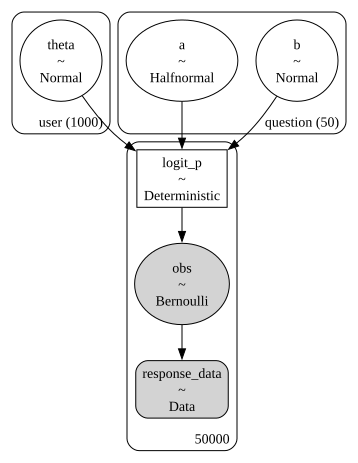

In [28]:
coords = {'user':users, 'question':questions}

model1 = pm.Model(coords=coords)

with model1:
    response_data = pm.Data('response_data', response)
    
    #能力値（受験者ごと）
    theta = pm.Normal('theta', mu=0, sigma=1, dims='user')
    
    #識別力（設問ごと）
    a =pm.HalfNormal('a', sigma=1, dims='question')
    
    #困難度（設問ごと）
    b = pm.Normal('b', mu=0, sigma=1, dims='question')
    
    #logit_pの計算
    logit_p = pm.Deterministic('logit_p', a[question_idx] * theta[user_idx] - b[question_idx])
    
    #ベルヌーイ分布の定義
    obs = pm.Bernoulli('obs', logit_p=logit_p, observed=response_data)

g = pm.model_to_graphviz(model1)
display(g)

In [29]:
%%time

with model1:
    idata1 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 173 seconds.


CPU times: total: 16.5 s
Wall time: 3min 5s


C:\Users\kzapp\AppData\Local\Temp\ipykernel_14896\833626772.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


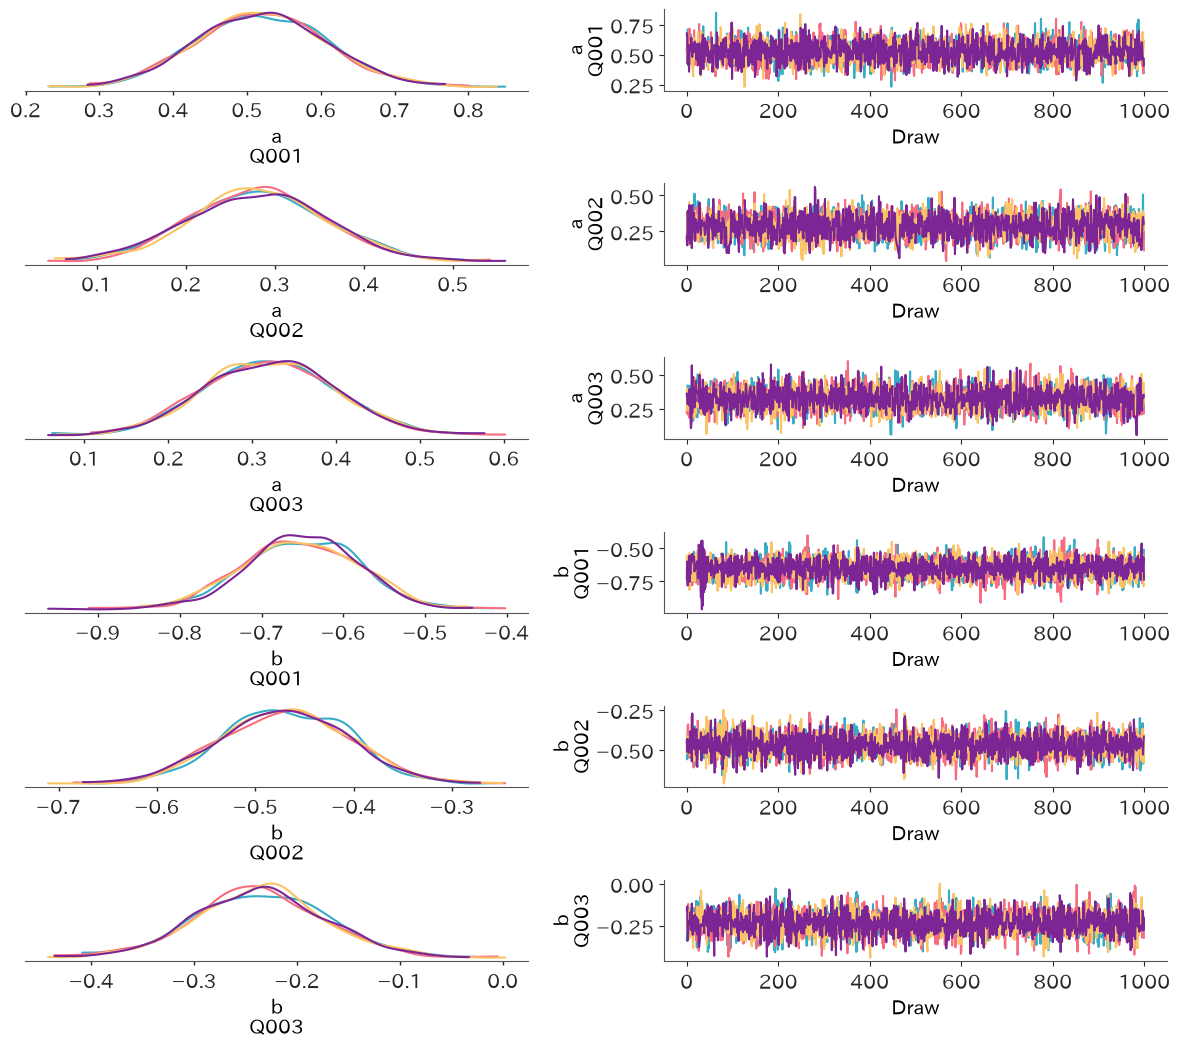

In [34]:
coords_q = {'question':['Q001', 'Q002', 'Q003']}
azp.plot_trace_dist(
    idata1, var_names=['a', 'b'], coords=coords_q, compact=False
)
plt.tight_layout()